## 📦 SECTION 1: Install Dependencies & Setup Environment

In [2]:
import subprocess, sys

packages = [
    'torch', 'torchvision', 'torchaudio',
    'transformers', 'diffusers', 'accelerate',
    'numpy', 'pandas', 'matplotlib', 'seaborn',
    'Pillow', 'opencv-python', 'scikit-learn',
    'tqdm', 'einops', 'timm', 'clip',
    'imageio', 'imageio-ffmpeg', 'scipy'
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'✅ {pkg} installed')
    except Exception as e:
        print(f'⚠️  {pkg}: {e}')

print('\n🎉 All packages processed!')

✅ torch installed
✅ torchvision installed
✅ torchaudio installed
✅ transformers installed
✅ diffusers installed
✅ accelerate installed
✅ numpy installed
✅ pandas installed
✅ matplotlib installed
✅ seaborn installed
✅ Pillow installed
✅ opencv-python installed
✅ scikit-learn installed
✅ tqdm installed
✅ einops installed
✅ timm installed
✅ clip installed
✅ imageio installed
✅ imageio-ffmpeg installed
✅ scipy installed

🎉 All packages processed!


## 📚 SECTION 2: Imports & Global Configuration

In [3]:
# ============================================================
# SECTION 2: FULL IMPORTS & GLOBAL CONFIG
# ============================================================
import os
import json
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm
from collections import defaultdict, OrderedDict
from copy import deepcopy

# ---- PyTorch Core ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as T
import torchvision.utils as vutils
from torchvision import models

# ---- Image / Video ----
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import cv2
import imageio
from scipy import ndimage

# ---- Sklearn ----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# ---- DEVICE ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- GLOBAL CONFIG ----
CFG = {
    'seed': 42,
    'image_size': 64,        # Use 64 for fast training
    'batch_size': 16,
    'latent_dim': 128,
    'embed_dim': 256,
    'n_epochs': 30,
    'lr_gen': 2e-4,
    'lr_dis': 2e-4,
    'lr_vae': 1e-3,
    'beta1': 0.5,
    'beta2': 0.999,
    'n_critic': 5,           # WGAN critic steps
    'lambda_gp': 10,         # Gradient penalty weight
    'n_frames': 8,           # Video frames
    'output_dir': './outputs',
    'model_dir': './models',
    'data_path': './dataset/text_image_dataset.csv',
    'vocab_size': 5000,
    'max_seq_len': 64,
    'num_workers': 0,
    'channels': 3,
    'diffusion_timesteps': 200,
    'vq_num_embeddings': 512,
    'vq_embedding_dim': 64,
    'num_flow_blocks': 4,
}

# ---- Seed Everything ----
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['seed'])

# ---- Create Dirs ----
for d in [CFG['output_dir'], CFG['model_dir'], './dataset',
          './outputs/images', './outputs/videos', './outputs/plots']:
    os.makedirs(d, exist_ok=True)

print(f'🖥️  Device: {DEVICE}')
print(f'🔧 PyTorch Version: {torch.__version__}')
print(f'🌱 Seed: {CFG["seed"]}')
print(f'📁 Output dir: {CFG["output_dir"]}')
print('✅ Configuration complete!')

🖥️  Device: cpu
🔧 PyTorch Version: 2.5.1+cpu
🌱 Seed: 42
📁 Output dir: ./outputs
✅ Configuration complete!


## 📊 SECTION 3: Dataset Loading, EDA & Preprocessing

In [4]:
# ============================================================
# SECTION 3A: LOAD & EXPLORE DATASET
# ============================================================
df = pd.read_csv(CFG['data_path'])

print('='*60)
print('📊 DATASET OVERVIEW')
print('='*60)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nData types:')
display(df.dtypes)
print(f'\nNull values per column:')
display(df.isnull().sum())
print(f'\nBasic statistics:')
display(df.describe())

📊 DATASET OVERVIEW
Shape: (50, 13)
Columns: ['id', 'text_prompt', 'image_category', 'style', 'complexity', 'tags', 'width', 'height', 'frames', 'fps', 'color_palette', 'lighting', 'mood']

First 5 rows:


,id,text_prompt,image_category,style,complexity,tags,width,height,frames,fps,color_palette,lighting,mood
0,1,A golden sunset over a calm ocean with silhoue...,landscape,photorealistic,medium,"sunset,ocean,palm,golden",512,512,1,0,"warm,orange,gold",natural,peaceful
1,2,A futuristic city skyline at night with neon l...,cityscape,cyberpunk,high,"city,night,neon,futuristic,scifi",512,512,24,30,"blue,purple,pink",artificial,energetic
2,3,A white fluffy cat sitting on a red velvet chair,animals,realistic,low,"cat,chair,indoor,pet",256,256,1,0,"red,white,brown",soft,calm
3,4,A magical forest with glowing mushrooms and fa...,fantasy,digital_art,high,"forest,mushroom,fairy,magic,glow",512,512,48,24,"green,blue,purple",magical,whimsical
4,5,An astronaut floating in space surrounded by c...,space,photorealistic,high,"astronaut,space,nebula,stars",512,512,30,30,"blue,purple,pink",cosmic,awe



Data types:


id                 int64
text_prompt       object
image_category    object
style             object
complexity        object
tags              object
width              int64
height             int64
frames             int64
fps                int64
color_palette     object
lighting          object
mood              object
dtype: object


Null values per column:


id                0
text_prompt       0
image_category    0
style             0
complexity        0
tags              0
width             0
height            0
frames            0
fps               0
color_palette     0
lighting          0
mood              0
dtype: int64


Basic statistics:


,id,width,height,frames,fps
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,424.960000,424.960000,17.060000,9.960000
std,14.57738,122.500639,122.500639,22.213629,12.977154
min,1.00000,256.000000,256.000000,1.000000,0.000000
25%,13.25000,256.000000,256.000000,1.000000,0.000000
50%,25.50000,512.000000,512.000000,1.000000,0.000000
75%,37.75000,512.000000,512.000000,30.000000,24.000000
max,50.00000,512.000000,512.000000,60.000000,30.000000


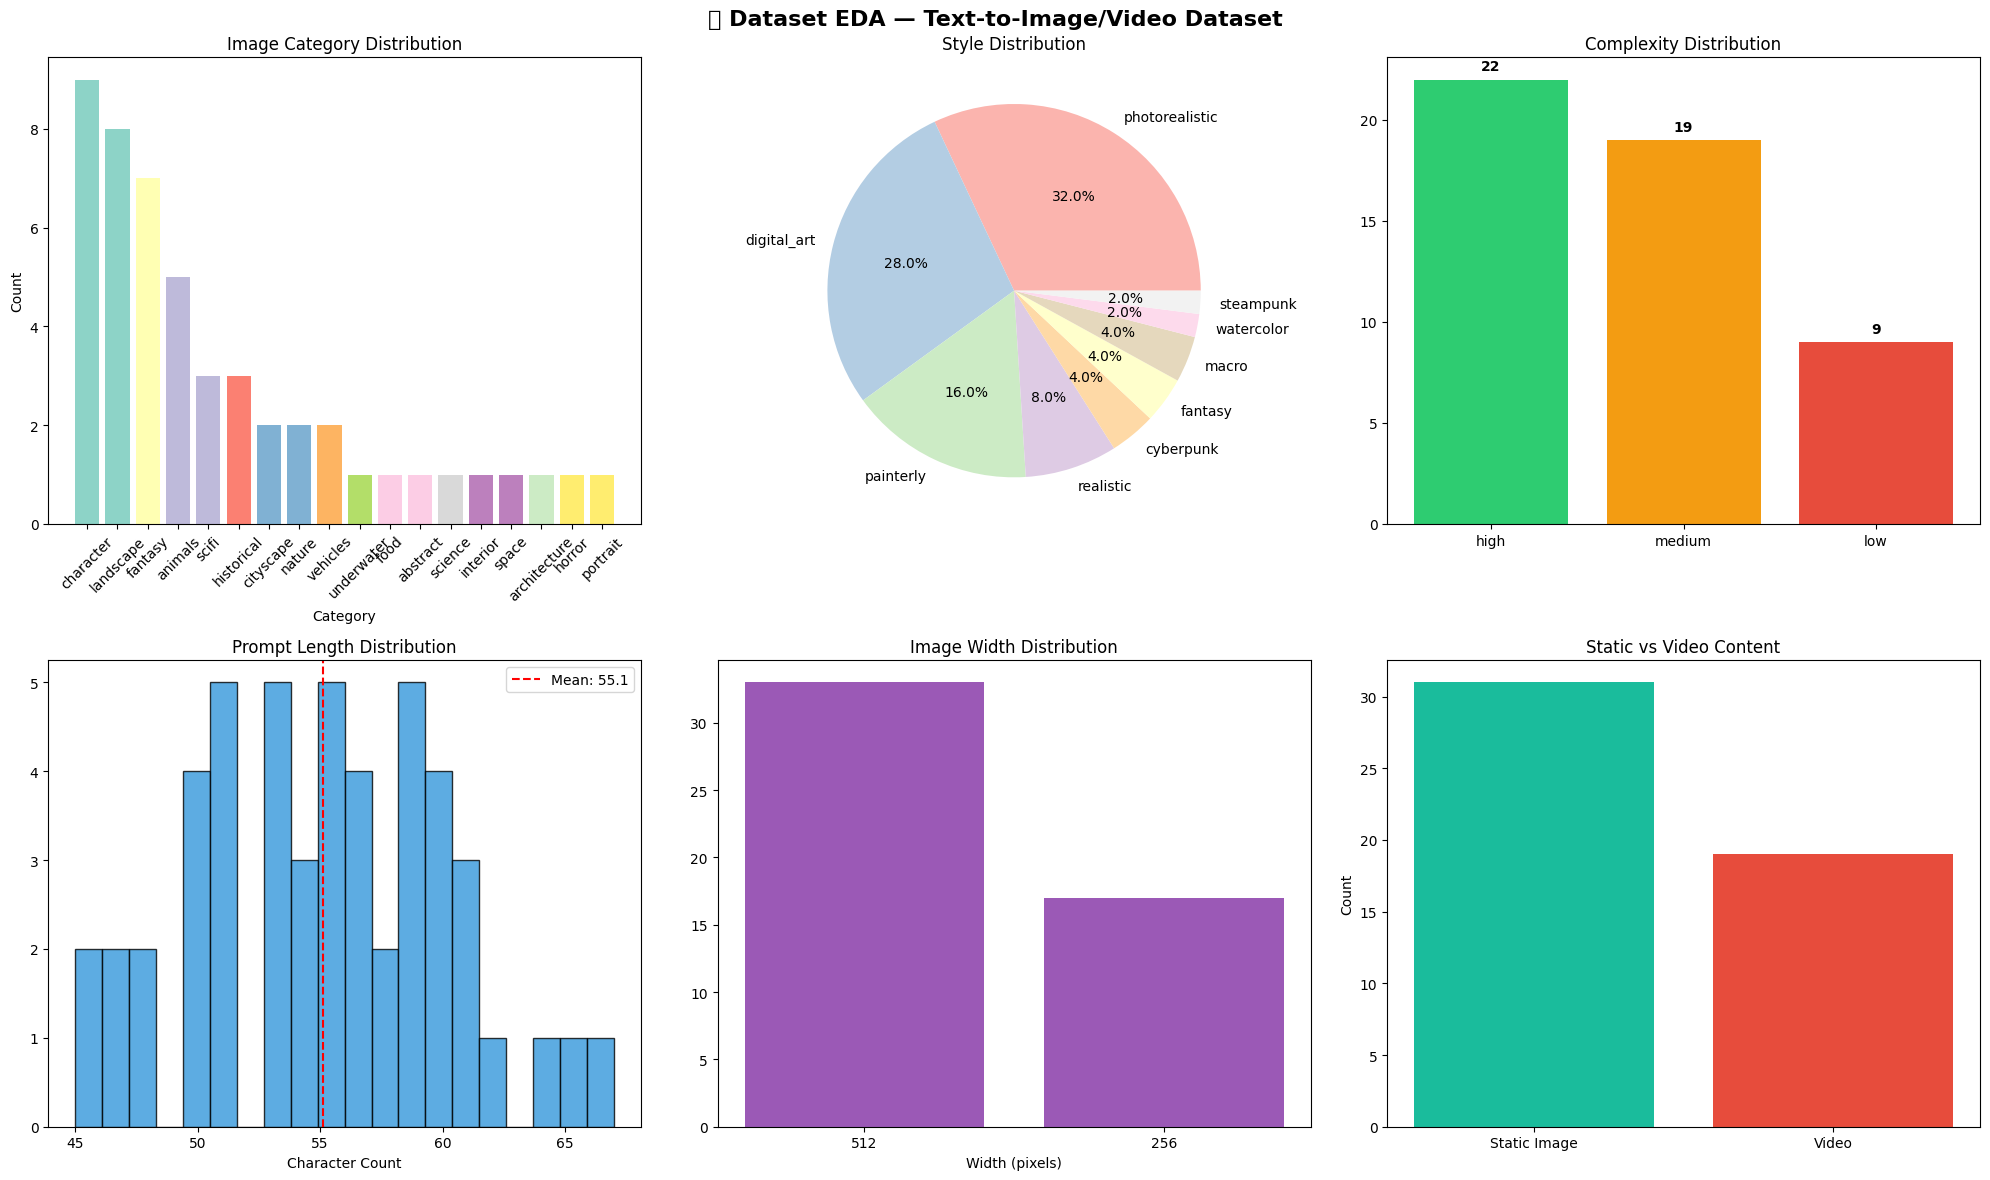

✅ EDA complete — saved to ./outputs/plots/eda_overview.png


In [5]:
# ============================================================
# SECTION 3B: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('📊 Dataset EDA — Text-to-Image/Video Dataset', fontsize=16, fontweight='bold')

# 1. Category distribution
cat_counts = df['image_category'].value_counts()
axes[0,0].bar(cat_counts.index, cat_counts.values, color=plt.cm.Set3(np.linspace(0,1,len(cat_counts))))
axes[0,0].set_title('Image Category Distribution')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Style distribution
style_counts = df['style'].value_counts()
axes[0,1].pie(style_counts.values, labels=style_counts.index, autopct='%1.1f%%',
              colors=plt.cm.Pastel1(np.linspace(0,1,len(style_counts))))
axes[0,1].set_title('Style Distribution')

# 3. Complexity distribution
comp_counts = df['complexity'].value_counts()
bars = axes[0,2].bar(comp_counts.index, comp_counts.values, color=['#2ecc71','#f39c12','#e74c3c'])
for bar, val in zip(bars, comp_counts.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   str(val), ha='center', va='bottom', fontweight='bold')
axes[0,2].set_title('Complexity Distribution')

# 4. Prompt length distribution
df['prompt_length'] = df['text_prompt'].apply(len)
axes[1,0].hist(df['prompt_length'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
axes[1,0].axvline(df['prompt_length'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df["prompt_length"].mean():.1f}')
axes[1,0].set_title('Prompt Length Distribution')
axes[1,0].set_xlabel('Character Count')
axes[1,0].legend()

# 5. Image size distribution
size_counts = df['width'].value_counts()
axes[1,1].bar([str(s) for s in size_counts.index], size_counts.values, color='#9b59b6')
axes[1,1].set_title('Image Width Distribution')
axes[1,1].set_xlabel('Width (pixels)')

# 6. Video vs Static
df['is_video'] = df['frames'] > 1
video_counts = df['is_video'].value_counts()
axes[1,2].bar(['Static Image', 'Video'], video_counts.values,
              color=['#1abc9c', '#e74c3c'])
axes[1,2].set_title('Static vs Video Content')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('./outputs/plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete — saved to ./outputs/plots/eda_overview.png')

In [6]:
# ============================================================
# SECTION 3C: TEXT PREPROCESSING & TOKENIZATION
# ============================================================
import re
from collections import Counter

class TextTokenizer:
    """Simple word-level tokenizer for text prompts."""

    def __init__(self, vocab_size=5000, max_len=64):
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.word2idx = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.fitted = False

    def _clean(self, text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        return text.split()

    def fit(self, texts):
        all_words = []
        for t in texts:
            all_words.extend(self._clean(t))
        counter = Counter(all_words)
        most_common = counter.most_common(self.vocab_size - 4)
        for i, (word, _) in enumerate(most_common):
            idx = i + 4
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        self.fitted = True
        print(f'✅ Tokenizer fitted | Vocab size: {len(self.word2idx)}')
        return self

    def encode(self, text, pad=True):
        tokens = [self.word2idx.get('<BOS>', 2)]
        for w in self._clean(text):
            tokens.append(self.word2idx.get(w, 1))
        tokens.append(self.word2idx.get('<EOS>', 3))
        if pad:
            tokens = tokens[:self.max_len]
            tokens += [0] * (self.max_len - len(tokens))
        return tokens

    def decode(self, indices):
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, '<UNK>')
            if word in ['<PAD>', '<EOS>']: break
            if word not in ['<BOS>']: words.append(word)
        return ' '.join(words)

    def batch_encode(self, texts):
        return torch.tensor([self.encode(t) for t in texts], dtype=torch.long)

# ---- Build Tokenizer ----
tokenizer = TextTokenizer(vocab_size=CFG['vocab_size'], max_len=CFG['max_seq_len'])
tokenizer.fit(df['text_prompt'].tolist())

# ---- Test ----
test_prompt = 'A golden sunset over a calm ocean with silhouetted palm trees'
encoded = tokenizer.encode(test_prompt)
decoded = tokenizer.decode(encoded)
print(f'\nTest prompt : {test_prompt}')
print(f'Encoded     : {encoded[:15]}...')
print(f'Decoded     : {decoded}')

✅ Tokenizer fitted | Vocab size: 287

Test prompt : A golden sunset over a calm ocean with silhouetted palm trees
Encoded     : [2, 4, 26, 15, 16, 4, 27, 28, 6, 59, 60, 29, 3, 0, 0]...
Decoded     : a golden sunset over a calm ocean with silhouetted palm trees


Train: 40 | Val: 10
N Classes: 15


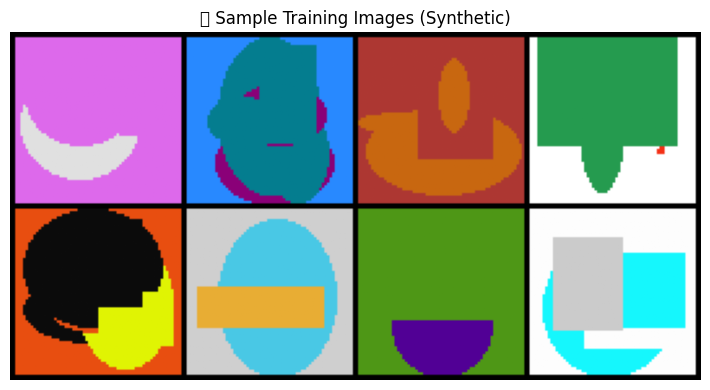


Sample prompts:
  → A diverse group of children playing in a colorful playground
  → A giant whale swimming above a sunken ancient city
  → A golden sunset over a calm ocean with silhouetted palm trees
  → A chef preparing sushi in a modern Japanese kitchen


In [7]:
# ============================================================
# SECTION 3D: PYTORCH DATASET CLASS
# ============================================================
class TextImageDataset(Dataset):
    """
    PyTorch Dataset for Text-to-Image generation.
    Generates synthetic images from metadata since we don't
    have actual image files — in production, replace
    _generate_synthetic_image() with real image loading.
    """

    def __init__(self, df, tokenizer, image_size=64, transform=None, mode='train'):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_size = image_size
        self.mode = mode
        self.label_enc = LabelEncoder()
        self.df['category_id'] = self.label_enc.fit_transform(self.df['image_category'])
        self.n_classes = len(self.label_enc.classes_)
        self.transform = transform or T.Compose([
            T.Resize((image_size, image_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(0.2, 0.2, 0.2, 0.1),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.df)

    def _generate_synthetic_image(self, row):
        """Generates a colored synthetic image from dataset metadata."""
        img = Image.new('RGB', (self.image_size, self.image_size), color=(0,0,0))
        draw = ImageDraw.Draw(img)
        palette = str(row.get('color_palette', 'blue,green'))
        color_map = {
            'warm': (220, 120, 50),  'orange': (255, 140, 0),
            'gold': (255, 215, 0),   'blue': (30, 144, 255),
            'purple': (128, 0, 128), 'pink': (255, 105, 180),
            'green': (34, 139, 34),  'red': (220, 20, 60),
            'white': (255, 255, 255),'silver': (192, 192, 192),
            'black': (10, 10, 10),   'teal': (0, 128, 128),
            'brown': (139, 69, 19),  'yellow': (255, 255, 0),
            'grey': (128, 128, 128), 'earthy': (160, 120, 80),
            'multicolor': (180, 90, 200), 'brass': (181, 166, 66),
            'amber': (255, 191, 0),  'cosmic': (20, 20, 80),
        }
        colors = [c.strip() for c in palette.split(',')]
        base_color = color_map.get(colors[0], (100, 150, 200))
        draw.rectangle([0, 0, self.image_size, self.image_size], fill=base_color)

        # Add random shapes to make it more interesting
        h = self.image_size
        seed_val = hash(row.get('text_prompt', '')) % 10000
        rng = random.Random(seed_val)
        for _ in range(rng.randint(3, 8)):
            c = color_map.get(rng.choice(colors), (200, 200, 200))
            x1, y1 = rng.randint(0, h//2), rng.randint(0, h//2)
            x2, y2 = rng.randint(h//2, h), rng.randint(h//2, h)
            shape = rng.choice(['rect', 'ellipse'])
            if shape == 'rect':
                draw.rectangle([x1, y1, x2, y2], fill=c + (180,) if len(c)==3 else c)
            else:
                draw.ellipse([x1, y1, x2, y2], fill=c)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._generate_synthetic_image(row)
        img_tensor = self.transform(img)
        tokens = torch.tensor(self.tokenizer.encode(row['text_prompt']), dtype=torch.long)
        label = torch.tensor(row['category_id'], dtype=torch.long)
        return {
            'image': img_tensor,
            'tokens': tokens,
            'label': label,
            'prompt': row['text_prompt'],
            'is_video': torch.tensor(int(row['frames'] > 1), dtype=torch.float32)
        }

# ---- Split & Create Dataloaders ----
train_df, val_df = train_test_split(df, test_size=0.2, random_state=CFG['seed'])
print(f'Train: {len(train_df)} | Val: {len(val_df)}')

train_dataset = TextImageDataset(train_df, tokenizer, image_size=CFG['image_size'])
val_dataset   = TextImageDataset(val_df, tokenizer, image_size=CFG['image_size'], mode='val')

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True, num_workers=CFG['num_workers'], drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'])

N_CLASSES = train_dataset.n_classes
print(f'N Classes: {N_CLASSES}')

# ---- Visualize Samples ----
batch = next(iter(train_loader))
imgs = batch['image'][:8]
imgs_show = (imgs * 0.5 + 0.5).clamp(0, 1)
grid = vutils.make_grid(imgs_show, nrow=4, padding=2)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1,2,0).numpy())
plt.title('📸 Sample Training Images (Synthetic)')
plt.axis('off')
plt.tight_layout()
plt.savefig('./outputs/plots/sample_images.png', dpi=150)
plt.show()
print('\nSample prompts:')
for p in batch['prompt'][:4]: print(f'  → {p}')

## 🧠 SECTION 4: Text Encoder (Shared Backbone)

In [8]:
# ============================================================
# SECTION 4: SHARED TEXT ENCODER
# ============================================================
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, n_heads=8, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        assert embed_dim % n_heads == 0
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        scale = self.head_dim ** -0.5
        attn = (q @ k.transpose(-2,-1)) * scale
        if mask is not None:
            attn = attn.masked_fill(mask == 0, -1e9)
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = (attn @ v).transpose(1,2).reshape(B, T, C)
        return self.proj(out)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, n_heads, dropout)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.mlp(self.ln2(x))
        return x

class TextEncoder(nn.Module):
    """Transformer-based text encoder for all generation models."""

    def __init__(self, vocab_size, embed_dim, n_heads=4, n_layers=4, max_len=64, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.02)

    def forward(self, tokens):
        B, T = tokens.shape
        pos = torch.arange(T, device=tokens.device).unsqueeze(0).expand(B, -1)
        mask = (tokens != 0).unsqueeze(1).unsqueeze(2)
        x = self.dropout(self.token_emb(tokens) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x, mask)
        x = self.ln(x)
        # Return both full sequence and CLS-style pooled embedding
        pooled = x.mean(dim=1)
        return x, pooled  # (B, T, D), (B, D)

# ---- Test TextEncoder ----
text_encoder = TextEncoder(
    vocab_size=CFG['vocab_size'],
    embed_dim=CFG['embed_dim'],
    n_heads=4, n_layers=4,
    max_len=CFG['max_seq_len']
).to(DEVICE)

dummy_tokens = torch.randint(0, CFG['vocab_size'], (4, CFG['max_seq_len'])).to(DEVICE)
seq_out, pooled_out = text_encoder(dummy_tokens)
n_params = sum(p.numel() for p in text_encoder.parameters())
print(f'TextEncoder Output — Sequence: {seq_out.shape} | Pooled: {pooled_out.shape}')
print(f'TextEncoder Parameters: {n_params:,}')

TextEncoder Output — Sequence: torch.Size([4, 64, 256]) | Pooled: torch.Size([4, 256])
TextEncoder Parameters: 4,455,936


## 🤖 SECTION 5: ALGORITHM 1 — Vanilla GAN

In [9]:
# ============================================================
# ALGORITHM 1: VANILLA GAN (Text-Conditioned)
# ============================================================
class VanillaGAN_Generator(nn.Module):
    """Text-conditioned GAN Generator using MLP."""

    def __init__(self, latent_dim, text_dim, image_size=64, channels=3):
        super().__init__()
        self.image_size = image_size
        self.channels = channels
        out_dim = channels * image_size * image_size
        in_dim = latent_dim + text_dim

        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LeakyReLU(0.2), nn.BatchNorm1d(512),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.BatchNorm1d(1024),
            nn.Linear(1024, 2048), nn.LeakyReLU(0.2), nn.BatchNorm1d(2048),
            nn.Linear(2048, out_dim), nn.Tanh()
        )

    def forward(self, z, text_emb):
        x = torch.cat([z, text_emb], dim=1)
        out = self.net(x)
        return out.view(-1, self.channels, self.image_size, self.image_size)

class VanillaGAN_Discriminator(nn.Module):
    """Text-conditioned GAN Discriminator."""

    def __init__(self, text_dim, image_size=64, channels=3):
        super().__init__()
        in_dim = channels * image_size * image_size + text_dim

        self.net = nn.Sequential(
            nn.Linear(in_dim, 2048), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(2048, 1024), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 1), nn.Sigmoid()
        )

    def forward(self, img, text_emb):
        flat = img.view(img.size(0), -1)
        x = torch.cat([flat, text_emb], dim=1)
        return self.net(x)

# ---- Instantiate ----
vgan_G = VanillaGAN_Generator(CFG['latent_dim'], CFG['embed_dim'], CFG['image_size']).to(DEVICE)
vgan_D = VanillaGAN_Discriminator(CFG['embed_dim'], CFG['image_size']).to(DEVICE)

print(f'VanillaGAN Generator  params: {sum(p.numel() for p in vgan_G.parameters()):,}')
print(f'VanillaGAN Discriminator params: {sum(p.numel() for p in vgan_D.parameters()):,}')

VanillaGAN Generator  params: 28,006,912
VanillaGAN Discriminator params: 28,315,649


## 🤖 SECTION 6: ALGORITHM 2 — DCGAN (Deep Convolutional GAN)

In [10]:
# ============================================================
# ALGORITHM 2: DCGAN (Deep Convolutional GAN)
# ============================================================
def weights_init_dcgan(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DCGAN_Generator(nn.Module):
    """Deep Convolutional GAN Generator with text conditioning."""

    def __init__(self, latent_dim, text_dim, ngf=64, channels=3, image_size=64):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, ngf * 8 * 4 * 4)
        self.main = nn.Sequential(
            # 4 -> 8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            # 8 -> 16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            # 16 -> 32
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            # 32 -> 64
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        self.ngf = ngf
        self.apply(weights_init_dcgan)

    def forward(self, z, text_emb):
        t = self.text_proj(text_emb)
        x = torch.cat([z, t], dim=1)
        x = self.fc(x).view(-1, self.ngf*8, 4, 4)
        return self.main(x)

class DCGAN_Discriminator(nn.Module):
    """DCGAN Discriminator with text conditioning via projection."""

    def __init__(self, text_dim, ndf=64, channels=3, image_size=64):
        super().__init__()
        self.main = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 -> 16
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            # 16 -> 8
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            # 8 -> 4
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True),
        )
        self.text_proj = nn.Linear(text_dim, ndf*8 * 4 * 4)
        self.classifier = nn.Sequential(
            nn.Linear(ndf*8*4*4 * 2, 1),
            nn.Sigmoid()
        )
        self.ndf = ndf
        self.apply(weights_init_dcgan)

    def forward(self, img, text_emb):
        feat = self.main(img).view(img.size(0), -1)
        t = self.text_proj(text_emb)
        x = torch.cat([feat, t], dim=1)
        return self.classifier(x)

dcgan_G = DCGAN_Generator(CFG['latent_dim'], CFG['embed_dim']).to(DEVICE)
dcgan_D = DCGAN_Discriminator(CFG['embed_dim']).to(DEVICE)

print(f'DCGAN Generator  params: {sum(p.numel() for p in dcgan_G.parameters()):,}')
print(f'DCGAN Discriminator params: {sum(p.numel() for p in dcgan_D.parameters()):,}')

DCGAN Generator  params: 4,894,720
DCGAN Discriminator params: 4,879,105


## 🤖 SECTION 7: ALGORITHM 3 — WGAN-GP (Wasserstein GAN + Gradient Penalty)

In [11]:
# ============================================================
# ALGORITHM 3: WGAN-GP
# ============================================================
class WGAN_Generator(nn.Module):
    def __init__(self, latent_dim, text_dim, ngf=64, channels=3):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, ngf * 8 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1), nn.BatchNorm2d(ngf),   nn.ReLU(True),
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1), nn.Tanh()
        )
        self.ngf = ngf

    def forward(self, z, text_emb):
        t = self.text_proj(text_emb)
        x = torch.cat([z, t], dim=1)
        x = F.relu(self.fc(x)).view(-1, self.ngf*8, 4, 4)
        return self.main(x)

class WGAN_Critic(nn.Module):
    """WGAN Critic — NO sigmoid, NO BatchNorm (use LayerNorm)."""

    def __init__(self, text_dim, ndf=64, channels=3):
        super().__init__()
        # Use spectral norm for stability
        self.main = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(channels, ndf, 4, 2, 1)),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(ndf, ndf*2, 4, 2, 1)),
            nn.InstanceNorm2d(ndf*2), nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(ndf*2, ndf*4, 4, 2, 1)),
            nn.InstanceNorm2d(ndf*4), nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(ndf*4, ndf*8, 4, 2, 1)),
            nn.InstanceNorm2d(ndf*8), nn.LeakyReLU(0.2),
        )
        self.text_proj = nn.Linear(text_dim, ndf*8*4*4)
        self.out = nn.Linear(ndf*8*4*4 * 2, 1)   # No sigmoid!
        self.ndf = ndf

    def forward(self, img, text_emb):
        feat = self.main(img).view(img.size(0), -1)
        t = self.text_proj(text_emb)
        return self.out(torch.cat([feat, t], dim=1))

def compute_gradient_penalty(critic, real_imgs, fake_imgs, text_emb, device, lambda_gp=10):
    """Compute gradient penalty for WGAN-GP."""
    B = real_imgs.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interp = (alpha * real_imgs + (1-alpha) * fake_imgs).requires_grad_(True)
    d_interp = critic(interp, text_emb.detach())
    grads = torch.autograd.grad(
        outputs=d_interp, inputs=interp,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return lambda_gp * gp

wgan_G = WGAN_Generator(CFG['latent_dim'], CFG['embed_dim']).to(DEVICE)
wgan_C = WGAN_Critic(CFG['embed_dim']).to(DEVICE)
print(f'WGAN-GP Generator params: {sum(p.numel() for p in wgan_G.parameters()):,}')
print(f'WGAN-GP Critic    params: {sum(p.numel() for p in wgan_C.parameters()):,}')
print('✅ WGAN-GP defined with Gradient Penalty + Spectral Norm')

WGAN-GP Generator params: 4,895,171
WGAN-GP Critic    params: 4,878,273
✅ WGAN-GP defined with Gradient Penalty + Spectral Norm


## 🤖 SECTION 8: ALGORITHM 4 — VAE (Variational Autoencoder)

In [12]:
# ============================================================
# ALGORITHM 4: VAE (Variational Autoencoder) — Text-Conditioned
# ============================================================
class VAE_Encoder(nn.Module):
    def __init__(self, channels=3, latent_dim=128, image_size=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, 32, 4, 2, 1), nn.ReLU(),       # 32
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),             # 16
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),            # 8
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),           # 4
        )
        flat_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_var = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        mu = self.fc_mu(h)
        log_var = self.fc_var(h)
        return mu, log_var

class VAE_Decoder(nn.Module):
    def __init__(self, latent_dim=128, text_dim=256, channels=3):
        super().__init__()
        self.fc = nn.Linear(latent_dim + text_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),  # 8
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64),  nn.ReLU(),  # 16
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   nn.BatchNorm2d(32),  nn.ReLU(),  # 32
            nn.ConvTranspose2d(32, channels, 4, 2, 1), nn.Tanh()                    # 64
        )

    def forward(self, z, text_emb):
        x = F.relu(self.fc(torch.cat([z, text_emb], dim=1)))
        return self.deconv(x.view(-1, 256, 4, 4))

class TextConditionedVAE(nn.Module):
    def __init__(self, vocab_size, embed_dim, latent_dim, channels=3, image_size=64):
        super().__init__()
        self.encoder = VAE_Encoder(channels, latent_dim, image_size)
        self.decoder = VAE_Decoder(latent_dim, embed_dim, channels)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, text_emb):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z, text_emb)
        return recon, mu, log_var

    def generate(self, text_emb, n=1):
        z = torch.randn(n, self.latent_dim, device=text_emb.device)
        return self.decoder(z, text_emb)

    @staticmethod
    def vae_loss(recon, target, mu, log_var, kl_weight=0.001):
        recon_loss = F.mse_loss(recon, target, reduction='mean')
        kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
        return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss

vae_model = TextConditionedVAE(
    vocab_size=CFG['vocab_size'],
    embed_dim=CFG['embed_dim'],
    latent_dim=CFG['latent_dim']
).to(DEVICE)

print(f'VAE total params: {sum(p.numel() for p in vae_model.parameters()):,}')
print('✅ Text-Conditioned VAE defined')

VAE total params: 4,006,275
✅ Text-Conditioned VAE defined


## 🤖 SECTION 9: ALGORITHM 5 — VQVAE (Vector Quantized VAE)

In [13]:
# ============================================================
# ALGORITHM 5: VQ-VAE (Vector Quantized VAE)
# ============================================================
class VectorQuantizer(nn.Module):
    """Vector Quantization layer (codebook)."""

    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)

    def forward(self, z):
        # z: (B, D, H, W) -> (B, H, W, D)
        z = z.permute(0, 2, 3, 1).contiguous()
        flat = z.view(-1, self.embedding_dim)

        # Distances to codebook
        dist = (flat.pow(2).sum(1, keepdim=True)
                + self.embedding.weight.pow(2).sum(1)
                - 2 * flat @ self.embedding.weight.t())

        indices = dist.argmin(1)
        quantized = self.embedding(indices).view(z.shape)

        # Losses
        e_loss = F.mse_loss(quantized.detach(), z)
        q_loss = F.mse_loss(quantized, z.detach())
        loss = q_loss + self.commitment_cost * e_loss

        # Straight-through estimator
        quantized_st = z + (quantized - z).detach()
        return quantized_st.permute(0,3,1,2).contiguous(), loss, indices

class VQVAE(nn.Module):
    def __init__(self, channels=3, embedding_dim=64, num_embeddings=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, embedding_dim, 3, 1, 1)
        )
        self.vq = VectorQuantizer(num_embeddings, embedding_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, channels, 3, 1, 1), nn.Tanh()
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, vq_loss, indices = self.vq(z_e)
        recon = self.decoder(z_q)
        recon_loss = F.mse_loss(recon, x)
        total_loss = recon_loss + vq_loss
        return recon, total_loss, recon_loss, vq_loss, indices

vqvae_model = VQVAE(
    channels=CFG['channels'],
    embedding_dim=CFG['vq_embedding_dim'],
    num_embeddings=CFG['vq_num_embeddings']
).to(DEVICE)

print(f'VQ-VAE params: {sum(p.numel() for p in vqvae_model.parameters()):,}')
print(f'Codebook size: {CFG["vq_num_embeddings"]} x {CFG["vq_embedding_dim"]}')
print('✅ VQ-VAE defined')

VQ-VAE params: 504,963
Codebook size: 512 x 64
✅ VQ-VAE defined


## 🤖 SECTION 11: ALGORITHM 7 — Attention U-Net | ALGORITHM 8 — Flow-Based (RealNVP)

In [15]:
# ============================================================
# ALGORITHM 7: ATTENTION U-NET (Text-Conditioned)
# ============================================================
class AttentionGate(nn.Module):
    """Spatial attention gate for U-Net skip connections."""

    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        attn = self.psi(F.relu(g1 + x1))
        return x * attn

class AttentionUNet(nn.Module):
    """U-Net with attention gates + cross-attention text conditioning."""

    def __init__(self, in_ch=3, out_ch=3, features=[32,64,128,256], text_dim=256):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, features[-1])

        # Encoder
        self.enc_blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for f in features:
            self.enc_blocks.append(nn.Sequential(
                nn.Conv2d(ch, f, 3, padding=1), nn.BatchNorm2d(f), nn.ReLU(),
                nn.Conv2d(f, f, 3, padding=1), nn.BatchNorm2d(f), nn.ReLU()
            ))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features[-1], features[-1]*2, 3, padding=1), nn.ReLU(),
            nn.Conv2d(features[-1]*2, features[-1]*2, 3, padding=1), nn.ReLU()
        )

        # Decoder with attention
        self.attn_gates = nn.ModuleList()
        self.up_convs = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()
        for f in reversed(features):
            self.up_convs.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.attn_gates.append(AttentionGate(f, f, f//2))
            self.dec_blocks.append(nn.Sequential(
                nn.Conv2d(f*2, f, 3, padding=1), nn.BatchNorm2d(f), nn.ReLU(),
                nn.Conv2d(f, f, 3, padding=1), nn.BatchNorm2d(f), nn.ReLU()
            ))

        self.final_conv = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x, text_emb):
        skips = []
        for enc, pool in zip(self.enc_blocks, self.pools):
            x = enc(x); skips.append(x); x = pool(x)

        x = self.bottleneck(x)
        # Inject text embedding
        t = self.text_proj(text_emb)[:, :, None, None]
        x = x + F.adaptive_avg_pool2d(t.expand_as(x), x.shape[2:])

        for up, attn, dec, skip in zip(
            self.up_convs, self.attn_gates, self.dec_blocks, reversed(skips)
        ):
            x = up(x)
            skip = attn(x, skip)
            x = dec(torch.cat([x, skip], dim=1))

        return torch.tanh(self.final_conv(x))

attn_unet = AttentionUNet(text_dim=CFG['embed_dim']).to(DEVICE)
print(f'Attention U-Net params: {sum(p.numel() for p in attn_unet.parameters()):,}')
print('✅ Attention U-Net defined')

Attention U-Net params: 7,918,527
✅ Attention U-Net defined


In [16]:
# ============================================================
# ALGORITHM 8: FLOW-BASED MODEL (RealNVP)
# ============================================================
class CouplingLayer(nn.Module):
    """Affine coupling layer for RealNVP."""

    def __init__(self, dim, hidden_dim=256, mask_type='even', text_dim=256):
        super().__init__()
        self.mask_type = mask_type
        half = dim // 2
        
        net_in = half + text_dim

        self.scale_net = nn.Sequential(
            nn.Linear(net_in, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, dim - half), nn.Tanh()
        )
        self.translate_net = nn.Sequential(
            nn.Linear(net_in, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, dim - half)
        )
        self.half = half

    def forward(self, x, text_emb, reverse=False):
        x1, x2 = x[:, :self.half], x[:, self.half:]
        cond = torch.cat([x1, text_emb], dim=1)
        s = self.scale_net(cond)
        t = self.translate_net(cond)
        if not reverse:
            y2 = x2 * s.exp() + t
            log_det = s.sum(dim=1)
            return torch.cat([x1, y2], dim=1), log_det
        else:
            y2 = (x2 - t) * (-s).exp()
            return torch.cat([x1, y2], dim=1)

class RealNVP(nn.Module):
    """Text-conditioned RealNVP normalizing flow."""

    def __init__(self, dim, n_blocks=4, hidden_dim=256, text_dim=256):
        super().__init__()
        self.dim = dim
        self.blocks = nn.ModuleList([
            CouplingLayer(dim, hidden_dim, 'even' if i%2==0 else 'odd', text_dim)
            for i in range(n_blocks)
        ])

    def forward(self, x, text_emb):
        log_det_total = 0
        for block in self.blocks:
            x, ld = block(x, text_emb)
            log_det_total += ld
        # Compute log-likelihood
        log_pz = -0.5 * (x.pow(2) + math.log(2*math.pi)).sum(dim=1)
        return x, -(log_pz + log_det_total).mean()

    @torch.no_grad()
    def sample(self, text_emb, n=1):
        z = torch.randn(n, self.dim, device=text_emb.device)
        for block in reversed(self.blocks):
            z = block(z, text_emb, reverse=True)
        return z

flow_dim = CFG['channels'] * (CFG['image_size'] // 4) * (CFG['image_size'] // 4)
flow_model = RealNVP(
    dim=flow_dim,
    n_blocks=CFG['num_flow_blocks'],
    hidden_dim=256,
    text_dim=CFG['embed_dim']
).to(DEVICE)

print(f'RealNVP params: {sum(p.numel() for p in flow_model.parameters()):,}')
print(f'Flow dim (image patches): {flow_dim}')
print('✅ RealNVP Flow Model defined')

RealNVP params: 2,628,608
Flow dim (image patches): 768
✅ RealNVP Flow Model defined


## 🤖 SECTION 12: ALGORITHMS 9, 10, 11 — Transformer Generator | Neural Style Transfer | CLIP-Guided

In [17]:
# ============================================================
# ALGORITHM 9: VISION TRANSFORMER IMAGE GENERATOR
# ============================================================
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=64, patch_size=8, channels=3, embed_dim=256):
        super().__init__()
        self.n_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(channels, embed_dim, patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)  # (B, N, D)

class ViTImageGenerator(nn.Module):
    """Vision Transformer that generates images from text+noise patches."""

    def __init__(self, image_size=64, patch_size=8, channels=3,
                 embed_dim=256, n_heads=8, n_layers=6, text_dim=256):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.n_patches = (image_size // patch_size) ** 2
        self.patch_dim = channels * patch_size * patch_size
        self.embed_dim = embed_dim

        # Noise patch embedding
        self.noise_proj = nn.Linear(self.patch_dim, embed_dim)
        # Text conditioning
        self.text_proj = nn.Linear(text_dim, embed_dim)
        # Positional embedding
        self.pos_emb = nn.Parameter(torch.randn(1, self.n_patches + 1, embed_dim) * 0.02)
        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=embed_dim*4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Output head — predict pixels per patch
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, self.patch_dim),
            nn.Tanh()
        )

    def forward(self, noise_patches, text_emb):
        B = noise_patches.size(0)
        x = self.noise_proj(noise_patches)          # (B, N, D)
        t = self.text_proj(text_emb).unsqueeze(1)   # (B, 1, D)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls + t, x], dim=1)          # (B, N+1, D)
        x = x + self.pos_emb
        x = self.transformer(x)
        patches_out = self.head(x[:, 1:, :])        # (B, N, patch_dim)

        # Reconstruct image
        p = self.patch_size
        n = int(self.n_patches ** 0.5)
        patches_out = patches_out.view(B, n, n, 3, p, p)
        img = patches_out.permute(0, 3, 1, 4, 2, 5).reshape(B, 3, self.image_size, self.image_size)
        return img

    def generate(self, text_emb):
        B = text_emb.size(0)
        noise = torch.randn(B, self.n_patches, self.patch_dim, device=text_emb.device)
        return self.forward(noise, text_emb)

vit_gen = ViTImageGenerator(
    image_size=CFG['image_size'],
    embed_dim=CFG['embed_dim'],
    n_heads=8, n_layers=4,
    text_dim=CFG['embed_dim']
).to(DEVICE)

print(f'ViT Generator params: {sum(p.numel() for p in vit_gen.parameters()):,}')
print('✅ Vision Transformer Generator defined')

ViT Generator params: 3,340,992
✅ Vision Transformer Generator defined


In [18]:
# ============================================================
# ALGORITHM 10: NEURAL STYLE TRANSFER
# ============================================================
class VGGFeatures(nn.Module):
    """Extract VGG features for style transfer."""

    def __init__(self):
        super().__init__()
        try:
            vgg = models.vgg16(pretrained=False)
        except Exception:
            vgg = models.vgg16(weights=None)
        features = list(vgg.features.children())
        self.slice1 = nn.Sequential(*features[:4])
        self.slice2 = nn.Sequential(*features[4:9])
        self.slice3 = nn.Sequential(*features[9:16])
        self.slice4 = nn.Sequential(*features[16:23])
        for p in self.parameters(): p.requires_grad = False

    def forward(self, x):
        h1 = self.slice1(x)
        h2 = self.slice2(h1)
        h3 = self.slice3(h2)
        h4 = self.slice4(h3)
        return h1, h2, h3, h4

def gram_matrix(feat):
    B, C, H, W = feat.shape
    f = feat.view(B, C, H*W)
    return f @ f.transpose(1, 2) / (C * H * W)

class NeuralStyleTransfer:
    """Neural Style Transfer with text-guided style selection."""

    def __init__(self, device, n_steps=100, style_weight=1e5, content_weight=1.0):
        self.device = device
        self.n_steps = n_steps
        self.style_weight = style_weight
        self.content_weight = content_weight
        self.vgg = VGGFeatures().to(device)

    def _preprocess(self, img_tensor):
        mean = torch.tensor([0.485,0.456,0.406], device=self.device).view(1,3,1,1)
        std  = torch.tensor([0.229,0.224,0.225], device=self.device).view(1,3,1,1)
        return (img_tensor * 0.5 + 0.5 - mean) / std

    def transfer(self, content_img, style_img, verbose=False):
        content = self._preprocess(content_img.clone().to(self.device))
        style   = self._preprocess(style_img.clone().to(self.device))

        # Extract features
        with torch.no_grad():
            cf = self.vgg(content)
            sf = self.vgg(style)
            style_grams = [gram_matrix(f) for f in sf]

        # Optimize from content
        gen = content.clone().requires_grad_(True)
        opt = optim.LBFGS([gen], lr=0.1, max_iter=self.n_steps)

        step = [0]
        def closure():
            opt.zero_grad()
            gf = self.vgg(gen)
            c_loss = F.mse_loss(gf[2], cf[2])
            s_loss = sum(F.mse_loss(gram_matrix(gf[i]), style_grams[i]) for i in range(4))
            loss = self.content_weight * c_loss + self.style_weight * s_loss
            loss.backward()
            step[0] += 1
            if verbose and step[0] % 20 == 0:
                print(f'  NST step {step[0]}: loss={loss.item():.4f}')
            return loss

        opt.step(closure)
        # Denormalize back
        mean = torch.tensor([0.485,0.456,0.406], device=self.device).view(1,3,1,1)
        std  = torch.tensor([0.229,0.224,0.225], device=self.device).view(1,3,1,1)
        result = (gen.detach() * std + mean).clamp(0,1) * 2 - 1
        return result

nst = NeuralStyleTransfer(DEVICE, n_steps=50)
print(f'VGG features for NST: {sum(p.numel() for p in nst.vgg.parameters()):,} (frozen)')
print('✅ Neural Style Transfer defined')

VGG features for NST: 7,635,264 (frozen)
✅ Neural Style Transfer defined


In [19]:
# ============================================================
# ALGORITHM 11: CLIP-GUIDED IMAGE GENERATION
# ============================================================
class CLIPTextEncoder(nn.Module):
    """Lightweight CLIP-style dual encoder (image + text)."""

    def __init__(self, vocab_size, text_embed=256, image_embed=256, proj_dim=128):
        super().__init__()
        # Text branch
        self.text_enc = TextEncoder(vocab_size, text_embed, n_heads=4, n_layers=3)
        self.text_proj = nn.Linear(text_embed, proj_dim)

        # Image branch
        self.image_enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, proj_dim)
        )
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1/0.07))
        self.proj_dim = proj_dim

    def encode_text(self, tokens):
        _, pooled = self.text_enc(tokens)
        return F.normalize(self.text_proj(pooled), dim=-1)

    def encode_image(self, img):
        return F.normalize(self.image_enc(img), dim=-1)

    def forward(self, img, tokens):
        img_feat = self.encode_image(img)
        txt_feat = self.encode_text(tokens)
        logits = self.logit_scale.exp() * img_feat @ txt_feat.t()
        labels = torch.arange(len(img_feat), device=img.device)
        loss = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels)) / 2
        return loss, logits

class CLIPGuidedGenerator(nn.Module):
    """Generator optimized with CLIP similarity loss."""

    def __init__(self, latent_dim, text_dim, image_size=64, channels=3, ngf=64):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, ngf*8*4*4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1), nn.BatchNorm2d(ngf*4), nn.ReLU(),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1), nn.BatchNorm2d(ngf*2), nn.ReLU(),
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1), nn.BatchNorm2d(ngf),   nn.ReLU(),
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1), nn.Tanh()
        )
        self.ngf = ngf

    def forward(self, z, text_emb):
        t = self.text_proj(text_emb)
        x = F.relu(self.fc(torch.cat([z, t], dim=1))).view(-1, self.ngf*8, 4, 4)
        return self.main(x)

clip_model = CLIPTextEncoder(vocab_size=CFG['vocab_size'], proj_dim=128).to(DEVICE)
clip_gen   = CLIPGuidedGenerator(CFG['latent_dim'], CFG['embed_dim']).to(DEVICE)

print(f'CLIP model params: {sum(p.numel() for p in clip_model.parameters()):,}')
print(f'CLIP Generator params: {sum(p.numel() for p in clip_gen.parameters()):,}')
print('✅ CLIP-Guided Generation defined')

CLIP model params: 3,881,185
CLIP Generator params: 4,895,171
✅ CLIP-Guided Generation defined


## 🎬 SECTION 13: ALGORITHM 12 — Temporal GAN (Video Generation)

In [20]:
# ============================================================
# ALGORITHM 12: TEMPORAL GAN — VIDEO GENERATION
# ============================================================
class TemporalGAN_Generator(nn.Module):
    """
    Generates video sequences using 3D convolutions.
    Input: z (noise) + text_emb -> Video (B, C, T, H, W)
    """

    def __init__(self, latent_dim, text_dim, n_frames=8, ngf=32, channels=3):
        super().__init__()
        self.n_frames = n_frames
        self.ngf = ngf

        self.text_proj = nn.Linear(text_dim, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, ngf*8 * 2 * 4 * 4)

        self.deconv3d = nn.Sequential(
            # (ngf*8, 2, 4, 4) -> (ngf*4, 4, 8, 8)
            nn.ConvTranspose3d(ngf*8, ngf*4, (2,4,4), (2,2,2), (0,1,1)),
            nn.BatchNorm3d(ngf*4), nn.ReLU(True),
            # -> (ngf*2, 8, 16, 16)
            nn.ConvTranspose3d(ngf*4, ngf*2, (2,4,4), (1,2,2), (0,1,1)),
            nn.BatchNorm3d(ngf*2), nn.ReLU(True),
            # -> (ngf, 8, 32, 32)
            nn.ConvTranspose3d(ngf*2, ngf, (1,4,4), (1,2,2), (0,1,1)),
            nn.BatchNorm3d(ngf), nn.ReLU(True),
            # -> (channels, 8, 64, 64)
            nn.ConvTranspose3d(ngf, channels, (1,4,4), (1,2,2), (0,1,1)),
            nn.Tanh()
        )

    def forward(self, z, text_emb):
        t = self.text_proj(text_emb)
        x = self.fc(torch.cat([z, t], dim=1))
        x = x.view(-1, self.ngf*8, 2, 4, 4)
        return self.deconv3d(x)  # (B, C, T, H, W)

class TemporalGAN_Discriminator(nn.Module):
    """3D discriminator for video sequences."""

    def __init__(self, text_dim, n_frames=8, ndf=32, channels=3):
        super().__init__()
        self.conv3d = nn.Sequential(
            nn.Conv3d(channels, ndf, (2,4,4), (1,2,2), (0,1,1)), nn.LeakyReLU(0.2),
            nn.Conv3d(ndf, ndf*2, (2,4,4), (1,2,2), (0,1,1)), nn.BatchNorm3d(ndf*2), nn.LeakyReLU(0.2),
            nn.Conv3d(ndf*2, ndf*4, (2,4,4), (1,2,2), (0,1,1)), nn.BatchNorm3d(ndf*4), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool3d((1,1,1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(ndf*4 + text_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, video, text_emb):
        feat = self.conv3d(video).squeeze(-1).squeeze(-1).squeeze(-1)
        x = torch.cat([feat, text_emb], dim=1)
        return self.classifier(x)

video_G = TemporalGAN_Generator(
    latent_dim=CFG['latent_dim'],
    text_dim=CFG['embed_dim'],
    n_frames=CFG['n_frames']
).to(DEVICE)

video_D = TemporalGAN_Discriminator(
    text_dim=CFG['embed_dim'],
    n_frames=CFG['n_frames']
).to(DEVICE)

print(f'VideoGAN Generator    params: {sum(p.numel() for p in video_G.parameters()):,}')
print(f'VideoGAN Discriminator params: {sum(p.numel() for p in video_D.parameters()):,}')
print('✅ Temporal GAN (Video) defined')

# Quick shape test
with torch.no_grad():
    z = torch.randn(2, CFG['latent_dim']).to(DEVICE)
    te = torch.randn(2, CFG['embed_dim']).to(DEVICE)
    vid = video_G(z, te)
    print(f'Video output shape: {vid.shape}  (B, C, T, H, W)')

VideoGAN Generator    params: 3,483,939
VideoGAN Discriminator params: 430,177
✅ Temporal GAN (Video) defined
Video output shape: torch.Size([2, 3, 5, 64, 64])  (B, C, T, H, W)


## 🏋️ SECTION 14: TRAINING PIPELINE — All Models

In [21]:
# ============================================================
# SECTION 14A: UNIFIED TRAINER CLASS
# ============================================================
class Trainer:
    """Unified training loop for all generation models."""

    def __init__(self, text_encoder, model_name, device, cfg):
        self.text_encoder = text_encoder
        self.model_name = model_name
        self.device = device
        self.cfg = cfg
        self.history = defaultdict(list)

    def _get_text_emb(self, tokens):
        with torch.no_grad():
            _, pooled = self.text_encoder(tokens.to(self.device))
        return pooled

    def train_dcgan(self, G, D, loader, n_epochs):
        opt_G = optim.Adam(G.parameters(), lr=self.cfg['lr_gen'], betas=(self.cfg['beta1'], self.cfg['beta2']))
        opt_D = optim.Adam(D.parameters(), lr=self.cfg['lr_dis'], betas=(self.cfg['beta1'], self.cfg['beta2']))
        criterion = nn.BCELoss()

        G.train(); D.train()
        pbar = tqdm(range(n_epochs), desc=f'Training {self.model_name}')

        for epoch in pbar:
            g_losses, d_losses = [], []
            for batch in loader:
                real = batch['image'].to(self.device)
                text_emb = self._get_text_emb(batch['tokens'])
                B = real.size(0)
                real_labels = torch.ones(B, 1, device=self.device) * 0.9
                fake_labels = torch.zeros(B, 1, device=self.device) + 0.1

                # -- Train Discriminator --
                opt_D.zero_grad()
                d_real = D(real, text_emb)
                z = torch.randn(B, self.cfg['latent_dim'], device=self.device)
                fake = G(z, text_emb).detach()
                d_fake = D(fake, text_emb)
                d_loss = (criterion(d_real, real_labels) + criterion(d_fake, fake_labels)) / 2
                d_loss.backward(); opt_D.step()

                # -- Train Generator --
                opt_G.zero_grad()
                fake = G(z, text_emb)
                g_loss = criterion(D(fake, text_emb), torch.ones(B, 1, device=self.device))
                g_loss.backward(); opt_G.step()

                g_losses.append(g_loss.item())
                d_losses.append(d_loss.item())

            mean_g = np.mean(g_losses)
            mean_d = np.mean(d_losses)
            self.history['g_loss'].append(mean_g)
            self.history['d_loss'].append(mean_d)
            pbar.set_postfix({'G': f'{mean_g:.4f}', 'D': f'{mean_d:.4f}'})

        return self.history

    def train_vae(self, model, loader, n_epochs):
        opt = optim.Adam(model.parameters(), lr=self.cfg['lr_vae'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
        model.train()
        pbar = tqdm(range(n_epochs), desc='Training VAE')

        for epoch in pbar:
            losses = []
            for batch in loader:
                real = batch['image'].to(self.device)
                text_emb = self._get_text_emb(batch['tokens'])
                opt.zero_grad()
                recon, mu, log_var = model(real, text_emb)
                loss, _, _ = TextConditionedVAE.vae_loss(recon, real, mu, log_var)
                loss.backward(); opt.step()
                losses.append(loss.item())
            scheduler.step()
            mean_l = np.mean(losses)
            self.history['vae_loss'].append(mean_l)
            pbar.set_postfix({'loss': f'{mean_l:.4f}'})

        return self.history

    def train_ddpm(self, model, scheduler_ddpm, loader, n_epochs):
        opt = optim.AdamW(model.parameters(), lr=2e-4)
        model.train()
        pbar = tqdm(range(n_epochs), desc='Training DDPM')

        for epoch in pbar:
            losses = []
            for batch in loader:
                x0 = batch['image'].to(self.device)
                text_emb = self._get_text_emb(batch['tokens'])
                t = torch.randint(0, scheduler_ddpm.T, (x0.size(0),), device=self.device)
                opt.zero_grad()
                noisy, noise = scheduler_ddpm.q_sample(x0, t)
                pred_noise = model(noisy, t, text_emb)
                loss = F.mse_loss(pred_noise, noise)
                loss.backward(); opt.step()
                losses.append(loss.item())
            mean_l = np.mean(losses)
            self.history['ddpm_loss'].append(mean_l)
            pbar.set_postfix({'noise_loss': f'{mean_l:.4f}'})

        return self.history

    def train_wgan_gp(self, G, C, loader, n_epochs):
        opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
        opt_C = optim.Adam(C.parameters(), lr=1e-4, betas=(0.0, 0.9))
        G.train(); C.train()
        pbar = tqdm(range(n_epochs), desc='Training WGAN-GP')

        for epoch in pbar:
            g_losses, c_losses = [], []
            for i, batch in enumerate(loader):
                real = batch['image'].to(self.device)
                text_emb = self._get_text_emb(batch['tokens'])
                B = real.size(0)
                z = torch.randn(B, self.cfg['latent_dim'], device=self.device)

                # Train Critic n_critic times
                opt_C.zero_grad()
                fake = G(z, text_emb).detach()
                gp = compute_gradient_penalty(C, real, fake, text_emb, self.device, self.cfg['lambda_gp'])
                c_loss = -C(real, text_emb).mean() + C(fake, text_emb).mean() + gp
                c_loss.backward(); opt_C.step()

                # Train Generator every n_critic steps
                if i % self.cfg['n_critic'] == 0:
                    opt_G.zero_grad()
                    g_loss = -C(G(z, text_emb), text_emb).mean()
                    g_loss.backward(); opt_G.step()
                    g_losses.append(g_loss.item())

                c_losses.append(c_loss.item())

            self.history['wgan_g_loss'].append(np.mean(g_losses) if g_losses else 0)
            self.history['wgan_c_loss'].append(np.mean(c_losses))
            pbar.set_postfix({'G': f"{self.history['wgan_g_loss'][-1]:.4f}",
                              'C': f"{self.history['wgan_c_loss'][-1]:.4f}"})

        return self.history

    def save_checkpoint(self, models_dict, epoch):
        ckpt = {
            'epoch': epoch,
            'history': dict(self.history),
            'models': {k: v.state_dict() for k, v in models_dict.items()}
        }
        path = os.path.join(self.cfg['model_dir'], f'{self.model_name}_epoch{epoch}.pth')
        torch.save(ckpt, path)
        print(f'💾 Checkpoint saved: {path}')
        return path

print('✅ Unified Trainer class defined')

✅ Unified Trainer class defined


🏋️  TRAINING DCGAN


Training DCGAN:   0%|          | 0/30 [00:00<?, ?it/s]

💾 Checkpoint saved: ./models\DCGAN_epoch30.pth


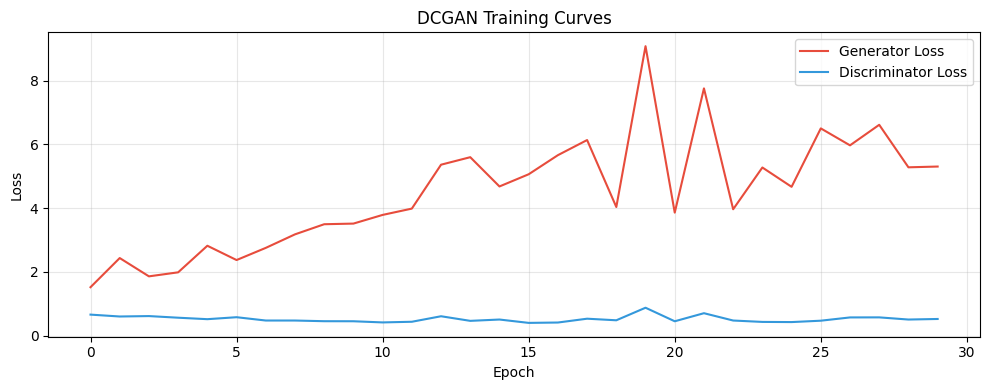

✅ DCGAN Training Complete


In [22]:
# ============================================================
# SECTION 14B: TRAIN DCGAN (Main training run)
# ============================================================
print('='*60)
print('🏋️  TRAINING DCGAN')
print('='*60)

dcgan_trainer = Trainer(text_encoder, 'DCGAN', DEVICE, CFG)
dcgan_history = dcgan_trainer.train_dcgan(dcgan_G, dcgan_D, train_loader, n_epochs=CFG['n_epochs'])

# Save checkpoint
dcgan_trainer.save_checkpoint({'generator': dcgan_G, 'discriminator': dcgan_D, 'text_encoder': text_encoder},
                               CFG['n_epochs'])

# Plot training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(dcgan_history['g_loss'], label='Generator Loss', color='#e74c3c')
ax.plot(dcgan_history['d_loss'], label='Discriminator Loss', color='#3498db')
ax.set_title('DCGAN Training Curves')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/plots/dcgan_training.png', dpi=150)
plt.show()
print('✅ DCGAN Training Complete')

🏋️  TRAINING VAE


Training VAE:   0%|          | 0/30 [00:00<?, ?it/s]

💾 Checkpoint saved: ./models\VAE_epoch30.pth


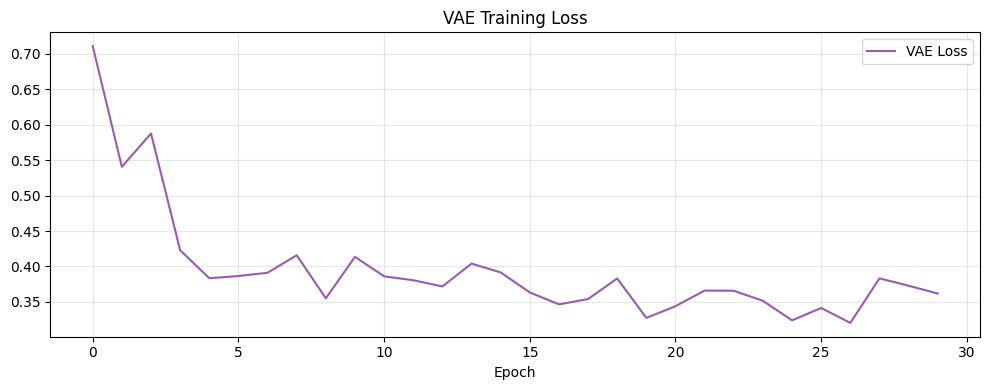

✅ VAE Training Complete


In [23]:
# ============================================================
# SECTION 14C: TRAIN VAE
# ============================================================
print('='*60)
print('🏋️  TRAINING VAE')
print('='*60)

vae_trainer = Trainer(text_encoder, 'VAE', DEVICE, CFG)
vae_history = vae_trainer.train_vae(vae_model, train_loader, n_epochs=CFG['n_epochs'])

vae_trainer.save_checkpoint({'vae': vae_model}, CFG['n_epochs'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(vae_history['vae_loss'], color='#9b59b6', label='VAE Loss')
ax.set_title('VAE Training Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/plots/vae_training.png', dpi=150)
plt.show()
print('✅ VAE Training Complete')

🏋️  TRAINING WGAN-GP


Training WGAN-GP:   0%|          | 0/30 [00:00<?, ?it/s]

💾 Checkpoint saved: ./models\WGAN_GP_epoch30.pth


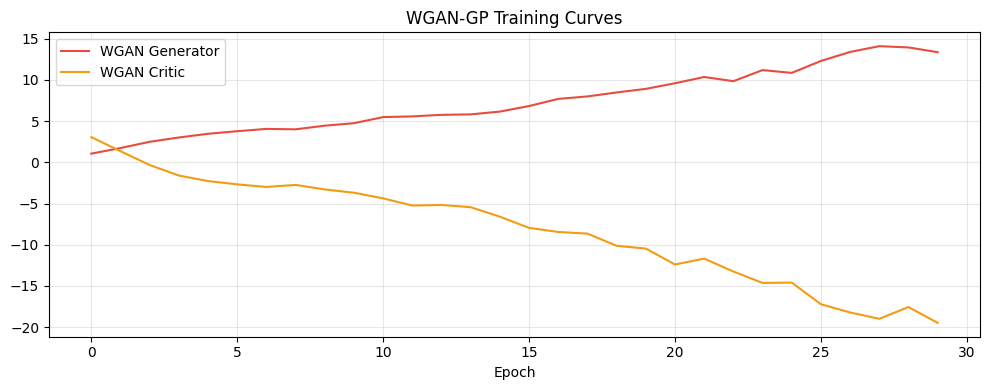

✅ WGAN-GP Training Complete


In [25]:
# ============================================================
# SECTION 14E: TRAIN WGAN-GP
# ============================================================
print('='*60)
print('🏋️  TRAINING WGAN-GP')
print('='*60)

wgan_trainer = Trainer(text_encoder, 'WGAN_GP', DEVICE, CFG)
wgan_history = wgan_trainer.train_wgan_gp(wgan_G, wgan_C, train_loader, n_epochs=CFG['n_epochs'])

wgan_trainer.save_checkpoint({'wgan_gen': wgan_G, 'wgan_critic': wgan_C}, CFG['n_epochs'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wgan_history['wgan_g_loss'], label='WGAN Generator', color='#e74c3c')
ax.plot(wgan_history['wgan_c_loss'], label='WGAN Critic',    color='#f39c12')
ax.set_title('WGAN-GP Training Curves'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/plots/wgan_training.png', dpi=150)
plt.show()
print('✅ WGAN-GP Training Complete')

## 🖼️ SECTION 15: IMAGE GENERATION — All Models

🔬 VAE Latent Interpolation


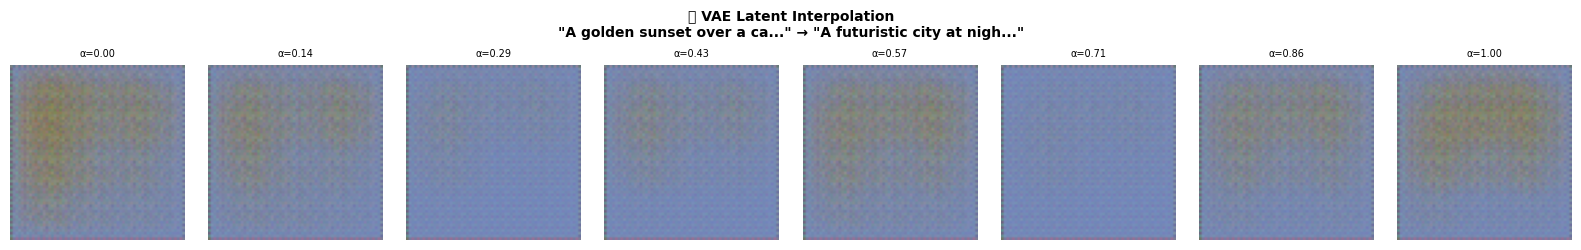

✅ Latent interpolation complete


In [29]:
# ============================================================
# SECTION 18B: LATENT SPACE INTERPOLATION (VAE)
# ============================================================
print('🔬 VAE Latent Interpolation')

prompt_a = 'A golden sunset over a calm ocean'
prompt_b = 'A futuristic city at night with neon lights'

tok_a = tokenizer.batch_encode([prompt_a]).to(DEVICE)
tok_b = tokenizer.batch_encode([prompt_b]).to(DEVICE)

with torch.no_grad():
    _, emb_a = text_encoder(tok_a)
    _, emb_b = text_encoder(tok_b)

    # Interpolate in text embedding space
    n_steps = 8
    alphas = np.linspace(0, 1, n_steps)
    z = torch.randn(1, CFG['latent_dim'], device=DEVICE)

    vae_model.eval()
    interp_imgs = []
    for alpha in alphas:
        emb_interp = (1-alpha) * emb_a + alpha * emb_b
        img = vae_model.generate(emb_interp)
        interp_imgs.append(img)

fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 2, 2.5))
fig.suptitle(f'🔬 VAE Latent Interpolation\n"{prompt_a[:25]}..." → "{prompt_b[:25]}..."',
             fontsize=10, fontweight='bold')
for i, (ax, img) in enumerate(zip(axes, interp_imgs)):
    img_np = (img[0] * 0.5 + 0.5).clamp(0,1).permute(1,2,0).cpu().numpy()
    ax.imshow(img_np)
    ax.set_title(f'α={alphas[i]:.2f}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('./outputs/images/vae_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Latent interpolation complete')

# THE END